# Does feature order matter?

Gradient boosting trained us to stop thinking about column order. A tree finds a feature by name and
splits on its value, so shuffling the columns changes nothing. This chapter asks whether that reflex
carries over to TabPFN. The short answer: less than you would hope and more than you would expect, and
the details are worth knowing.

**What's in here**

1. The gradient-boosting baseline: column order is invisible to trees.
2. Why TabPFN is different: it reads the row jointly, and the default checkpoint is not permutation-invariant.
3. The hidden default: a per-member shuffle averages the column order away.
4. A measured result: with the shuffle off, bundling two *interacting* features helps; a redundant pair does not.
5. The knife-edge: the interaction type, the exact column gap, and the shuffle all have to line up.
6. Real data, and the honest bottom line.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from tqdm import tqdm
from sklearn.metrics import log_loss
from tabpfn import TabPFNClassifier

## What gradient boosting taught us: order does not matter

A tree splits on one feature value at a time and finds that feature by name, not by position. Permute
the columns of the input, refit, and the model relabels which feature sits where but learns the same
structure, so the predictions match. Column order is a readability choice, never a modeling one. The cell
below makes the point: fit LightGBM, permute the columns of train and test the same way, refit, and the two probability vectors match exactly.

In [2]:
from lightgbm import LGBMClassifier

rng = np.random.RandomState(0)
n_features = 12
X_train = rng.randn(4000, n_features)
X_test = rng.randn(2000, n_features)

def product_label(feature_matrix):
    """Binary label from a product interaction plus two linear terms."""
    signal = (feature_matrix[:, 0] * feature_matrix[:, 1]
              + 0.7 * feature_matrix[:, 2] - 0.7 * feature_matrix[:, 3])
    return (signal > 0).astype(int)

y_train = product_label(X_train)
y_test = product_label(X_test)

column_permutation = rng.permutation(n_features)
gbm_plain = LGBMClassifier(n_estimators=200, verbose=-1).fit(X_train, y_train)
gbm_permuted = LGBMClassifier(n_estimators=200, verbose=-1).fit(X_train[:, column_permutation], y_train)
proba_plain = gbm_plain.predict_proba(X_test)[:, 1]
proba_permuted = gbm_permuted.predict_proba(X_test[:, column_permutation])[:, 1]

print("gradient boosting, plain vs column-permuted:")
print(f"  max |change in P(class 1)|: {np.max(np.abs(proba_plain - proba_permuted)):.2e}")
print(f"  test log-loss plain {log_loss(y_test, proba_plain):.4f} vs permuted {log_loss(y_test, proba_permuted):.4f}")

gradient boosting, plain vs column-permuted:
  max |change in P(class 1)|: 0.00e+00
  test log-loss plain 0.1001 vs permuted 0.1001


## TabPFN reads the row, so order is an input

A tree looks at one feature at a time. TabPFN reads the whole row at once and lets the features interact
inside a transformer, so where a feature sits in the row is part of what the model sees. The default
classifier is TabPFN v2, checkpoint version 3, and two of its parts depend on column order.

The input embedding fuses each column with its circular neighbours at offsets 1, 2 and 4 through a single
linear layer (`architectures/tabpfn_v3.py`, the `_group_features` step, `feature_group_size = 3`), so
columns that sit near each other in the order share an early representation. The cross-feature attention
then adds rotary position encodings over the column axis (`use_rope = True`), so columns close in the
order are treated as closer. Neither step is invariant to column order.

If that were the whole story, feature order would be a parameter you had to tune. It is not, because of
the next part.

### The default shuffles the order away

TabPFN builds its ensemble by handing each member a different view of the data. One of those knobs,
`FEATURE_SHIFT_METHOD`, permutes the feature columns per member, and its default is `"shuffle"`. Averaged
over members, the arbitrary column order washes out. To see this, we take one task, permute its input
columns a few times, and measure how much the prediction moves, once with the default shuffle and once
with it turned off (`FEATURE_SHIFT_METHOD=None`, which makes every member see the order we pass in).

First the task we will reuse throughout: the label is the sign of a product `a*b`, a genuine two-feature
interaction. Columns 0 and 1 hold noisy copies of `a` and `b`; the rest are pure noise.

In [3]:
def make_interaction_task(seed, n_train=200, n_test=600, n_noise=18, obs_noise=0.3):
    """Label is sign(a*b). Columns 0,1 are the interacting pair; the other n_noise columns are noise."""
    rng = np.random.RandomState(seed)
    a = rng.randn(n_train + n_test)
    b = rng.randn(n_train + n_test)
    label = (a * b > 0).astype(int)
    columns = [a + obs_noise * rng.randn(n_train + n_test),
               b + obs_noise * rng.randn(n_train + n_test)]
    columns += [rng.randn(n_train + n_test) for _ in range(n_noise)]
    feature_matrix = np.column_stack(columns)
    return feature_matrix[:n_train], label[:n_train], feature_matrix[n_train:], label[n_train:]

X_train, y_train, X_test, y_test = make_interaction_task(seed=0)
n_columns = X_train.shape[1]
shuffle_rng = np.random.RandomState(1)
permutations = [shuffle_rng.permutation(n_columns) for _ in range(5)]

def mean_probability_shift(feature_shift):
    """Average absolute change in P(class 1) when the input columns are permuted, vs the identity order."""
    def fit_predict(train_matrix, test_matrix):
        model = TabPFNClassifier(inference_config={"FEATURE_SHIFT_METHOD": feature_shift},
                                 n_estimators=16, random_state=0, auto_scale_n_estimators=False)
        model.fit(train_matrix, y_train)
        return model.predict_proba(test_matrix)[:, 1]
    base_proba = fit_predict(X_train, X_test)
    shifts = []
    for permutation in tqdm(permutations, desc=f"shift={feature_shift}"):
        permuted_proba = fit_predict(X_train[:, permutation], X_test[:, permutation])
        shifts.append(np.mean(np.abs(permuted_proba - base_proba)))
    return np.mean(shifts)

shift_default = mean_probability_shift("shuffle")
shift_off = mean_probability_shift(None)
print("mean |change in P(class 1)| under a column permutation:")
print(f"  default shuffle: {shift_default:.4f}")
print(f"  shuffle off:     {shift_off:.4f}")

mean |change in P(class 1)| under a column permutation:
  default shuffle: 0.0441
  shuffle off:     0.1496


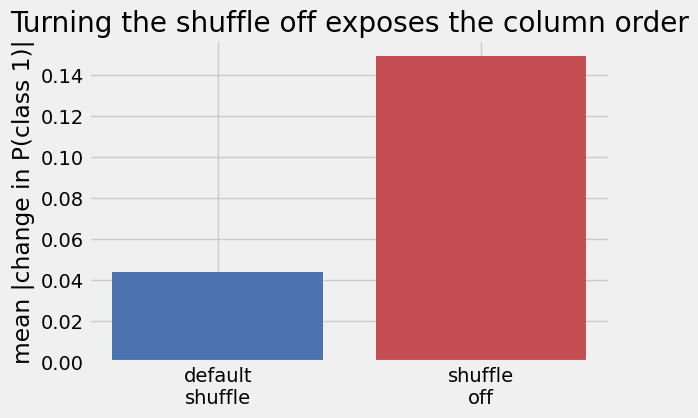

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.bar(["default\nshuffle", "shuffle\noff"], [shift_default, shift_off], color=["#4c72b0", "#c44e52"])
ax.set_ylabel("mean |change in P(class 1)|")
ax.set_title("Turning the shuffle off exposes the column order")
plt.tight_layout()
plt.show()

With the shuffle on, permuting the input barely moves the prediction: the ensemble has already averaged
over column orders. With it off, the same permutation moves it more than three times as much. The order dependence
is real, and the default hides it. Everything below sets `FEATURE_SHIFT_METHOD=None` so we can study the
order directly.

## With the shuffle off, does bundling related features help?

Here is the question a gradient-boosting habit suggests: if two features belong together, does placing
them next to each other help TabPFN? We test it on two kinds of "belong together". In the interaction
task above, the label is the product `a*b`. In a redundant task, the label is the sign of one latent seen
as two noisy copies, so the useful combination of the pair is just their average. We also add a third
task, `|a| > |b|`, a real pairwise interaction that is not a product.

For each task we place the two related columns at a fixed gap and sweep the gap, holding the data fixed
and changing only positions. Two small helpers do the placement and the scoring.

In [5]:
def order_columns(feature_matrix, placements):
    """Return the matrix with chosen columns moved to chosen positions: a pure permutation.

    placements is a list of (source_column, target_position). The remaining columns fill the other
    positions in their original order, so only positions change and never the data itself."""
    n_cols = feature_matrix.shape[1]
    order = [None] * n_cols
    placed = set(column for column, _ in placements)
    for column, position in placements:
        order[position] = column
    remaining = (c for c in range(n_cols) if c not in placed)
    for position in range(n_cols):
        if order[position] is None:
            order[position] = next(remaining)
    return feature_matrix[:, order]

def tabpfn_test_logloss(X_train, y_train, X_test, y_test, feature_shift):
    """Fit TabPFN with a chosen FEATURE_SHIFT_METHOD and return test log-loss.

    feature_shift=None turns off the per-member column shuffle, so every ensemble member sees the
    exact column order we pass in."""
    model = TabPFNClassifier(inference_config={"FEATURE_SHIFT_METHOD": feature_shift},
                             n_estimators=16, random_state=0, auto_scale_n_estimators=False)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    return log_loss(y_test, np.column_stack([1 - proba, proba]))

In [6]:
def make_redundant_task(seed, n_train=200, n_test=600, n_noise=18, obs_noise=1.5):
    """Label is sign(latent), with the latent observed twice with noise. Columns 0,1 are the copies."""
    rng = np.random.RandomState(seed)
    latent = rng.randn(n_train + n_test)
    label = (latent > 0).astype(int)
    columns = [latent + obs_noise * rng.randn(n_train + n_test),
               latent + obs_noise * rng.randn(n_train + n_test)]
    columns += [rng.randn(n_train + n_test) for _ in range(n_noise)]
    feature_matrix = np.column_stack(columns)
    return feature_matrix[:n_train], label[:n_train], feature_matrix[n_train:], label[n_train:]

def make_magnitude_task(seed, n_train=200, n_test=600, n_noise=18, obs_noise=0.3):
    """Label is |a| > |b|, a pairwise interaction that is not a product. Columns 0,1 are the pair."""
    rng = np.random.RandomState(seed)
    a = rng.randn(n_train + n_test)
    b = rng.randn(n_train + n_test)
    label = (np.abs(a) > np.abs(b)).astype(int)
    columns = [a + obs_noise * rng.randn(n_train + n_test),
               b + obs_noise * rng.randn(n_train + n_test)]
    columns += [rng.randn(n_train + n_test) for _ in range(n_noise)]
    feature_matrix = np.column_stack(columns)
    return feature_matrix[:n_train], label[:n_train], feature_matrix[n_train:], label[n_train:]

Read the figure as: test log-loss at each column gap, minus the log-loss when the pair sits far apart
(gap 6). Below zero means that spacing helped. The pair always starts at column 2; only the second
feature moves.

In [7]:
gaps = [1, 2, 3, 4, 6]
seeds = range(8)
anchor_position = 2
far_gap = 6

def logloss_by_gap(make_task):
    """Per-seed test log-loss at each column gap between the two related features, shuffle off."""
    curve = {}
    for gap in gaps:
        per_seed = []
        for seed in tqdm(seeds, desc=f"gap={gap}", leave=False):
            X_train, y_train, X_test, y_test = make_task(seed)
            placement = [(0, anchor_position), (1, anchor_position + gap)]
            per_seed.append(tabpfn_test_logloss(order_columns(X_train, placement), y_train,
                                                order_columns(X_test, placement), y_test, None))
        curve[gap] = np.array(per_seed)
    return curve

interaction_curve = logloss_by_gap(make_interaction_task)
redundant_curve = logloss_by_gap(make_redundant_task)
magnitude_curve = logloss_by_gap(make_magnitude_task)

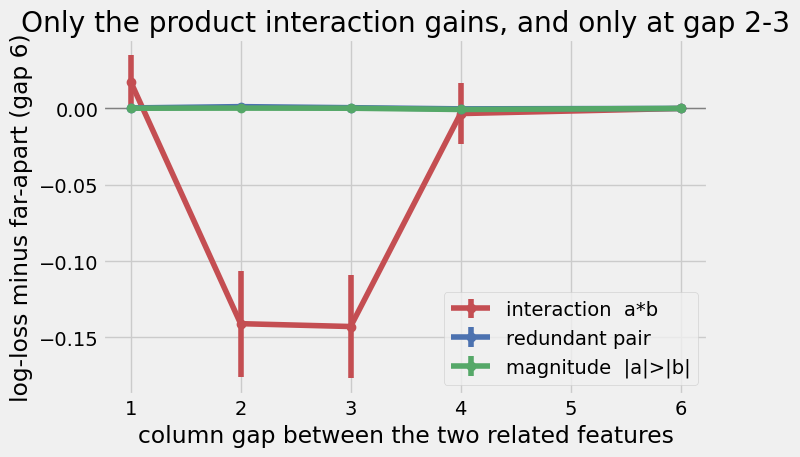

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
curves = [(interaction_curve, "interaction  a*b", "#c44e52"),
          (redundant_curve, "redundant pair", "#4c72b0"),
          (magnitude_curve, "magnitude  |a|>|b|", "#55a868")]
for curve, name, color in curves:
    relative = [curve[gap] - curve[far_gap] for gap in gaps]
    means = [block.mean() for block in relative]
    errors = [block.std() / np.sqrt(len(seeds)) for block in relative]
    ax.errorbar(gaps, means, yerr=errors, marker="o", label=name, color=color)
ax.axhline(0, color="0.5", lw=1)
ax.set_xlabel("column gap between the two related features")
ax.set_ylabel("log-loss minus far-apart (gap 6)")
ax.set_title("Only the product interaction gains, and only at gap 2-3")
ax.legend()
plt.tight_layout()
plt.show()

For the product interaction, placing the pair at a gap of 2 or 3 lowers log-loss by a clear margin, while
putting them right next to each other (gap 1) or far apart (gap 4 and beyond) does nothing. The redundant
pair and the magnitude interaction stay flat at every gap. Three facts fall out.

Bundling helps a product interaction, not redundancy, and not every interaction. The sweet spot is a
specific gap, not adjacency: the benefit tracks the {1,2,4} offsets the input embedding fuses, and the
pair has to straddle the offset-4 tap (gap 2 or 3) to gain. And gap 1, the placement a practitioner would
reach for first, is exactly the one that does nothing.

## It holds for several groups at once

The single-pair effect is modest. Put several interacting pairs in one task, with the label the sign of a
sum of products, and place each pair at its sweet-spot gap. Clustered beats scattered, and stays positive
as we add groups. The size is noisy and does not simply add up per group, but the sign is reliable.

In [9]:
def make_multi_interaction_task(seed, n_pairs=3, n_train=300, n_test=800, width=20, obs_noise=0.2):
    """Label is the sign of a sum of n_pairs products. Columns 0..2*n_pairs-1 are the interacting pairs."""
    rng = np.random.RandomState(seed)
    latents = [rng.randn(n_train + n_test) for _ in range(2 * n_pairs)]
    signal = sum(latents[2 * i] * latents[2 * i + 1] for i in range(n_pairs))
    label = (signal > 0).astype(int)
    columns = [latents[j] + obs_noise * rng.randn(n_train + n_test) for j in range(2 * n_pairs)]
    columns += [rng.randn(n_train + n_test) for _ in range(width - 2 * n_pairs)]
    feature_matrix = np.column_stack(columns)
    return feature_matrix[:n_train], label[:n_train], feature_matrix[n_train:], label[n_train:]

# each pair at gap 2 (clustered) vs every pair broken apart (scattered)
clustered_positions = [(0, 2), (1, 4), (2, 8), (3, 10), (4, 14), (5, 16)]
scattered_positions = [(0, 0), (1, 10), (2, 3), (3, 13), (4, 6), (5, 16)]

clustered_gain = []
for seed in tqdm(range(10), desc="clustered vs scattered"):
    X_train, y_train, X_test, y_test = make_multi_interaction_task(seed)
    loss_clustered = tabpfn_test_logloss(order_columns(X_train, clustered_positions), y_train,
                                         order_columns(X_test, clustered_positions), y_test, None)
    loss_scattered = tabpfn_test_logloss(order_columns(X_train, scattered_positions), y_train,
                                         order_columns(X_test, scattered_positions), y_test, None)
    clustered_gain.append(loss_scattered - loss_clustered)
clustered_gain = np.array(clustered_gain)
print("three interacting pairs, clustered vs scattered:")
print(f"  clustered lowers log-loss by {clustered_gain.mean():+.3f} "
      f"(better in {np.mean(clustered_gain > 0):.0%} of {len(clustered_gain)} seeds)")

three interacting pairs, clustered vs scattered:
  clustered lowers log-loss by +0.111 (better in 100% of 10 seeds)


### Why a product, and not redundancy or a magnitude test

The input embedding is a linear map of the fused columns. A linear combination `alpha*a + beta*b` cannot
be a product on its own, but squaring it, which a later nonlinearity can do, surfaces the cross term
`a*b`. Co-locating two features hands the model a shortcut to their product. A redundant pair only needs
an average, which the attention forms wherever the copies sit, and `|a| > |b|`, which is `a^2 - b^2`, has
no single-combination shortcut. That is the pattern the gap figure shows: the product gains, the other two
do not.

## Real data, and the honest bottom line

Two checks close the loop. First, keep the injected product label but swap the Gaussian interacting
features for standardized columns from the breast cancer dataset. If the gain is not an artifact of clean
Gaussian features, clustered should still beat scattered here.

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

real_columns = StandardScaler().fit_transform(load_breast_cancer().data)
interacting = real_columns[:, [0, 5, 10, 15, 20, 25]]
label_real = ((interacting[:, 0] * interacting[:, 1]
               + interacting[:, 2] * interacting[:, 3]
               + interacting[:, 4] * interacting[:, 5]) > 0).astype(int)
noise_columns = np.random.RandomState(0).randn(real_columns.shape[0], 14)
X_real = np.column_stack([interacting, noise_columns])

real_gain = []
for seed in tqdm(range(10), desc="real interacting features"):
    X_train, X_test, y_train, y_test = train_test_split(X_real, label_real, test_size=0.4, random_state=seed)
    loss_clustered = tabpfn_test_logloss(order_columns(X_train, clustered_positions), y_train,
                                         order_columns(X_test, clustered_positions), y_test, None)
    loss_scattered = tabpfn_test_logloss(order_columns(X_train, scattered_positions), y_train,
                                         order_columns(X_test, scattered_positions), y_test, None)
    real_gain.append(loss_scattered - loss_clustered)
real_gain = np.array(real_gain)
print("real interacting features (injected product label):")
print(f"  clustered lowers log-loss by {real_gain.mean():+.3f} (better in {np.mean(real_gain > 0):.0%} of seeds)")

real interacting features (injected product label):
  clustered lowers log-loss by +0.016 (better in 100% of seeds)


The gain survives real feature distributions, so it is not a Gaussian artifact. The harder test is a real
task end to end. We fetch sonar (60 numeric features), detect its strongest disjoint interacting pairs
with a gradient-boosting H-statistic, cluster those pairs at the sweet-spot gap, and compare against
scattering them. If real interactions were product-shaped and landed at the right gap, clustering would
win here too.

In [11]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.inspection import partial_dependence
from itertools import combinations

sonar = fetch_openml("sonar", version=1, as_frame=True, parser="auto")
X_sonar = StandardScaler().fit_transform(sonar.data.select_dtypes("number").values)
y_sonar = (sonar.target == sonar.target.unique()[0]).astype(int).values

def top_disjoint_interacting_pairs(X, y, n_pairs, n_top=10, grid=20):
    """Rank feature pairs by Friedman H-statistic from a gradient-boosting fit; return the strongest
    non-overlapping pairs."""
    booster = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, verbose=-1).fit(X, y)
    top_features = [int(f) for f in np.argsort(booster.feature_importances_)[::-1][:n_top]]
    def centered_pd(features):
        values = partial_dependence(booster, X, [features], grid_resolution=grid, kind="average")["average"][0]
        return values - values.mean()
    one_way = {f: centered_pd(f) for f in top_features}
    strengths = []
    for i, j in combinations(top_features, 2):
        joint = centered_pd((i, j))
        interaction = joint - one_way[i][:, None] - one_way[j][None, :]
        strengths.append((np.sqrt((interaction ** 2).sum() / ((joint ** 2).sum() + 1e-12)), i, j))
    strengths.sort(reverse=True)
    used, pairs = set(), []
    for _, i, j in strengths:
        if i not in used and j not in used:
            pairs.append((i, j))
            used.update({i, j})
        if len(pairs) == n_pairs:
            break
    return pairs

detected_pairs = top_disjoint_interacting_pairs(X_sonar, y_sonar, n_pairs=4)
print("detected interacting pairs:", detected_pairs)

sonar_clustered, sonar_scattered = [], []
scatter_a, scatter_b = [0, 14, 28, 42], [7, 21, 35, 49]
for group_index, (feature_a, feature_b) in enumerate(detected_pairs):
    sonar_clustered += [(feature_a, 2 + 6 * group_index), (feature_b, 4 + 6 * group_index)]
    sonar_scattered += [(feature_a, scatter_a[group_index]), (feature_b, scatter_b[group_index])]

splitter = StratifiedShuffleSplit(n_splits=10, train_size=150, random_state=0)
sonar_gain = []
for train_idx, test_idx in tqdm(list(splitter.split(X_sonar, y_sonar)), desc="sonar splits"):
    loss_clustered = tabpfn_test_logloss(order_columns(X_sonar[train_idx], sonar_clustered), y_sonar[train_idx],
                                         order_columns(X_sonar[test_idx], sonar_clustered), y_sonar[test_idx], None)
    loss_scattered = tabpfn_test_logloss(order_columns(X_sonar[train_idx], sonar_scattered), y_sonar[train_idx],
                                         order_columns(X_sonar[test_idx], sonar_scattered), y_sonar[test_idx], None)
    sonar_gain.append(loss_scattered - loss_clustered)
sonar_gain = np.array(sonar_gain)
print("sonar, clustering the detected pairs vs scattering:")
print(f"  clustered lowers log-loss by {sonar_gain.mean():+.4f} "
      f"+/- {sonar_gain.std() / np.sqrt(len(sonar_gain)):.4f} "
      f"(better in {np.mean(sonar_gain > 0):.0%} of splits)")

detected interacting pairs: [(35, 36), (11, 10), (44, 26), (47, 8)]


sonar, clustering the detected pairs vs scattering:
  clustered lowers log-loss by -0.0061 +/- 0.0098 (better in 70% of splits)


## What to do

Feature order is a real input to TabPFN, more than a gradient-boosting habit expects. As a lever, though,
it is fragile: it needs a product-shaped interaction, a specific column gap rather than plain adjacency,
and the per-member shuffle switched off. On the real task those conditions do not line up, and the
clustered order is within noise of scattered. The default shuffle exists precisely to spare you from the
arbitrary order.

So leave `FEATURE_SHIFT_METHOD` on its default and do not hand-order columns for TabPFN. Keep the
mechanism in mind for one practical case: if you ever run with the shuffle off, for speed or
reproducibility, two column orders can disagree, and now you know why and by how much.